# Pha Q′ (lần 5) — `T_theta` với **mask conditioning** (sửa nguyên nhân đã đo được)

Lần 4 (phân rã TE): variance TE của quantum cao vì hai nhánh full/reduced ÍT tương quan hơn MLP (0.765 vs 0.892) và `mi_full` nhiễu hơn ~1.5×. Sửa: `mask_conditioning=True` — sau mỗi lớp áp `RZ(mask_theta[l,q]·mask)` lên MỌI qubit (thay vì mask chỉ đi vào 1 qubit), +24 tham số (tổng 85), khởi tạo 0.

**Thí nghiệm sạch, đúng 1 biến đổi:** giữ nguyên 128 cửa sổ train, lr=0.03, 20 epoch, seed, 100 cửa sổ test, `eval_n_shuffles=20` như Quantum-128 lần 3 (MSE 0.0135, var 0.0124, corr 0.765...). MLP: MSE 0.0100, corr 0.892.

Cuối notebook có cell phân rã mi_full/mi_reduced để xem tương quan hai nhánh có tăng không. ~44 phút train + ~15 phút đo.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import generate_corpus, split_corpus_by_seed
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig
from pqrst.estimators.quantum.wrapper import QuantumStatisticsNetwork
from pqrst.evaluation.feature_space import collect_block_records, fit_pca

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = BASE / 'results' / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

N_QUBITS = 6
N_LAYERS = 4
N_WINDOW = 20
COUPLING_C = 0.6
NOISE_STD = 0.5

## 1. Sinh tập train/val nhỏ (1 cấu hình cố định)

In [2]:
corpus = generate_corpus(
    coupling_values=[COUPLING_C], noise_values=[NOISE_STD], n_values=[N_WINDOW],
    n_windows_per_cell=150, a=0.5, b=0.5, base_seed=700000,
)
train_windows, val_windows = split_corpus_by_seed(corpus, val_fraction=0.15, split_seed=1)
print(f'Train: {len(train_windows)}, Val: {len(val_windows)}')
print(f'TE ground truth (c={COUPLING_C}, noise={NOISE_STD}): {corpus[0].te_ground_truth:.4f} nats')

Train: 128, Val: 22
TE ground truth (c=0.6, noise=0.5): 0.1814 nats


## 2. Train `QuantumStatisticsNetwork` (ước tính ~55-65 phút — đã đo thử ở quy mô nhỏ hơn trước khi giao)

In [3]:
config = AmortizedTrainConfig(
    learning_rate=0.03, windows_per_batch=8, max_epochs=20, patience=20,
    eval_n_shuffles=5, final_estimate_last_k_epochs=3, seed=42,
)

start = time.time()
est_quantum, hist_quantum = train_amortized(
    train_windows, val_windows, config,
    model_factory=lambda: QuantumStatisticsNetwork(n_qubits=N_QUBITS, n_layers=N_LAYERS, mask_conditioning=True),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_quantum["train_loss_history"])}, '
      f'final_val_loss={hist_quantum["final_val_loss"]:.5f}')

Time: 3855.3s, epochs run: 20, final_val_loss=-0.15373


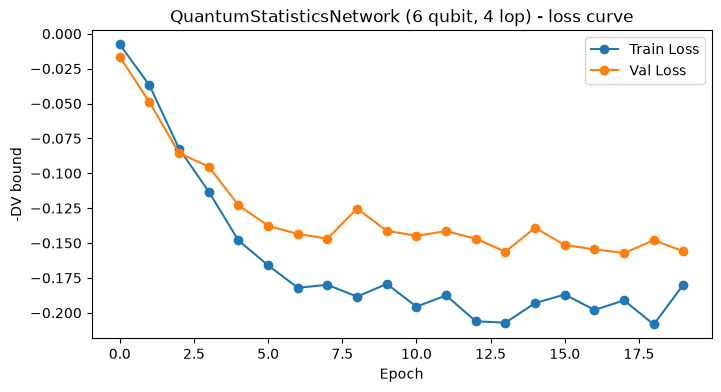

Loss di chuyen tu epoch dau den cuoi: 0.17207 (CO NGHIA - dang hoc)


In [4]:
plt.figure(figsize=(8, 4))
plt.plot(hist_quantum['train_loss_history'], label='Train Loss', marker='o')
plt.plot(hist_quantum['val_loss_history'], label='Val Loss', marker='o')
plt.xlabel('Epoch'); plt.ylabel('-DV bound'); plt.legend()
plt.title(f'QuantumStatisticsNetwork ({N_QUBITS} qubit, {N_LAYERS} lop) - loss curve')
plt.savefig(FIG_DIR / 'phase_p2_quantum_training_loss_maskcond.png', dpi=100)
plt.show()

loss_moved = abs(hist_quantum['train_loss_history'][-1] - hist_quantum['train_loss_history'][0])
print(f'Loss di chuyen tu epoch dau den cuoi: {loss_moved:.5f} '
      f'({"CO NGHIA - dang hoc" if loss_moved > 1e-3 else "CANH BAO: qua nho, kiem tra lai"})')

## 3. Kiểm tra gradient không biến mất (điều kiện thoát Pha Q′)

In [5]:
# Chay them 1 buoc forward+backward tren model DA TRAIN, tren 1 batch moi (chua
# tung thay) - kiem tra gradient tung nhom tham so con "song" (khong ve 0 het).
model = est_quantum.model
model.train()
w = train_windows[0]
y_t = torch.tensor(w.y_t, dtype=torch.float32).unsqueeze(-1)
x_lag = torch.tensor(w.x_lag, dtype=torch.float32).unsqueeze(-1)
y_lag = torch.tensor(w.y_lag, dtype=torch.float32).unsqueeze(-1)
mask = torch.ones_like(y_t)

out = model(y_t, x_lag, y_lag, mask)
out.sum().backward()

for name, p in model.named_parameters():
    g_norm = p.grad.norm().item() if p.grad is not None else float('nan')
    print(f'{name}: grad_norm={g_norm:.6f} {"[CANH BAO: gan 0]" if g_norm < 1e-6 else "OK"}')

encode_scale: grad_norm=25.797245 OK
theta: grad_norm=34.207474 OK
mask_theta: grad_norm=23.610207 OK
readout.weight: grad_norm=6.022477 OK
readout.bias: grad_norm=20.000000 OK


## 4. PCA-theo-khối trên `T_theta` (tái dùng công cụ từ Pha T.3b/P′.0b) — có cấu trúc theo `c` chưa?

So cua so danh gia PCA: 75


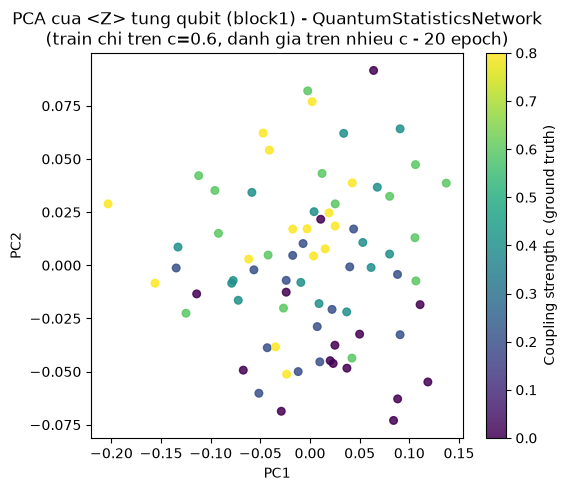

In [6]:
# Tap nho, nhieu muc coupling, CHI dung de danh gia (khong dung de train).
eval_corpus = generate_corpus(
    coupling_values=[0.0, 0.2, 0.4, 0.6, 0.8], noise_values=[NOISE_STD], n_values=[N_WINDOW],
    n_windows_per_cell=15, a=0.5, b=0.5, base_seed=900000,
)
samples = [(w.y_t, w.x_lag, w.y_lag, {'coupling_c': w.params['c']}) for w in eval_corpus]
print(f'So cua so danh gia PCA: {len(samples)}')

records = collect_block_records(model, samples, include_marginal=False)
Xp, pca, used = fit_pca(records, 'block1')
c_vals = [r['coupling_c'] for r in used]

plt.figure(figsize=(6, 5))
sca = plt.scatter(Xp[:, 0], Xp[:, 1], c=c_vals, cmap='viridis', s=30, alpha=0.85)
plt.colorbar(sca, label='Coupling strength c (ground truth)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'PCA cua <Z> tung qubit (block1) - QuantumStatisticsNetwork\n'
          f'(train chi tren c={COUPLING_C}, danh gia tren nhieu c - {len(hist_quantum["train_loss_history"])} epoch)')
plt.savefig(FIG_DIR / 'phase_p2_quantum_pca_by_coupling_maskcond.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Lưu checkpoint + đo TE ước lượng trên tập test độc lập

In [7]:
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import pandas as pd
from pqrst.baselines.ksg import KSGTEEstimator
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.evaluation.grid import evaluate_estimators_on_grid, summarize_grid

ckpt_dir = BASE / 'results' / 'checkpoints'; ckpt_dir.mkdir(parents=True, exist_ok=True)
torch.save({'state_dict': est_quantum.model.state_dict(), 'n_qubits': N_QUBITS, 'n_layers': N_LAYERS, 'mask_conditioning': True},
           ckpt_dir / 'theta_quantum_maskcond.pt')
print('Da luu theta_quantum_maskcond.pt')

test_corpus = generate_corpus(coupling_values=[COUPLING_C], noise_values=[NOISE_STD], n_values=[N_WINDOW],
                              n_windows_per_cell=100, a=0.5, b=0.5, base_seed=950000)
est_mlp = AmortizedTEEstimator.load(str(ckpt_dir / 'phi_amortized.pt'))
estimators = {'KSG': KSGTEEstimator(), 'MLP_Amortized': est_mlp, 'Quantum_maskcond': AmortizedTEEstimator(est_quantum.model, AmortizedTrainConfig(eval_n_shuffles=20))}
raw = evaluate_estimators_on_grid(estimators, test_corpus, progress=True)
summary = summarize_grid(raw)
summary[['estimator','n_valid','n_failed','bias','variance','mse']]

Da luu theta_quantum_maskcond.pt


Evaluating windows: 100%|██████████| 100/100 [14:36<00:00,  8.76s/it]


,estimator,n_valid,n_failed,bias,variance,mse
0,KSG,100,0,-0.082927,0.006347,0.013161
1,MLP_Amortized,100,0,-0.071676,0.004942,0.010030
2,Quantum_maskcond,100,0,-0.032856,0.011546,0.012510


In [8]:
te_gt = test_corpus[0].te_ground_truth
print(f'TE ground truth: {te_gt:.4f} nats (c={COUPLING_C}, N={N_WINDOW})')
for name, g in raw.groupby('estimator'):
    v = g['te_estimate'].dropna()
    print(f'{name:14s} mean={v.mean():.4f} std={v.std():.4f} bias={v.mean()-te_gt:+.4f} '
          f'mse={((v-te_gt)**2).mean():.5f} (n={len(v)})')
summary.to_csv(BASE/'results'/'tables'/'phase_p2_quantum_maskcond_eval.csv', index=False)

TE ground truth: 0.1814 nats (c=0.6, N=20)
KSG            mean=0.0985 std=0.0797 bias=-0.0829 mse=0.01316 (n=100)
MLP_Amortized  mean=0.1097 std=0.0703 bias=-0.0717 mse=0.01003 (n=100)
Quantum_maskcond mean=0.1485 std=0.1075 bias=-0.0329 mse=0.01251 (n=100)


In [9]:
from pqrst.estimators.mine.conditional import estimate_te_from_window
def decomp(model, name):
    F=[];R=[]
    for w in test_corpus:
        r=estimate_te_from_window(model,w.y_t,w.x_lag,w.y_lag,n_shuffles=20,seed=w.seed)
        F.append(r['mi_full']);R.append(r['mi_reduced'])
    F=np.array(F);R=np.array(R);te=F-R
    print(f'{name}: mi_full mean={F.mean():.3f} var={F.var(ddof=1):.5f} | mi_red mean={R.mean():.3f} var={R.var(ddof=1):.5f} | corr={np.corrcoef(F,R)[0,1]:.3f} | var(TE)={te.var(ddof=1):.5f}')
print('Tham chieu: MLP corr=0.892 var(TE)=0.0049 | Quantum-450 (khong mask cond) corr=0.765 var(TE)=0.0145')
print(f'GT mi_full={test_corpus[0].mi_full_ground_truth:.3f} mi_reduced={test_corpus[0].mi_reduced_ground_truth:.3f}')
decomp(est_mlp.model, 'MLP')
decomp(est_quantum.model, 'Quantum_maskcond')

Tham chieu: MLP corr=0.892 var(TE)=0.0049 | Quantum-450 (khong mask cond) corr=0.765 var(TE)=0.0145
GT mi_full=0.438 mi_reduced=0.256
MLP: mi_full mean=0.271 var=0.02154 | mi_red mean=0.162 var=0.01166 | corr=0.892 | var(TE)=0.00494
Quantum_maskcond: mi_full mean=0.267 var=0.02881 | mi_red mean=0.118 var=0.01095 | corr=0.794 | var(TE)=0.01155


## 7. Kết luận (đọc từ số liệu ở trên)

Đây là so sánh sức khoẻ ban đầu trên 1 cấu hình duy nhất, KHÔNG phải kết luận cuối. Báo Claude kết quả bảng trên.